In this notebook, we will be creating a CNN (Convolutional Neural Network) based classifier for the classification of CIFAR-10 dataset.

**About the dataset**

CIFAR-10 dataset is a subset of CIFAR-100 having 80 million images of 100 different objects. CIFAR-10 takes 60,000 images for 10 classes from the original dataset in which 50,000 images are for training and 10,000 images are for testing.

The classes in the dataset are -
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

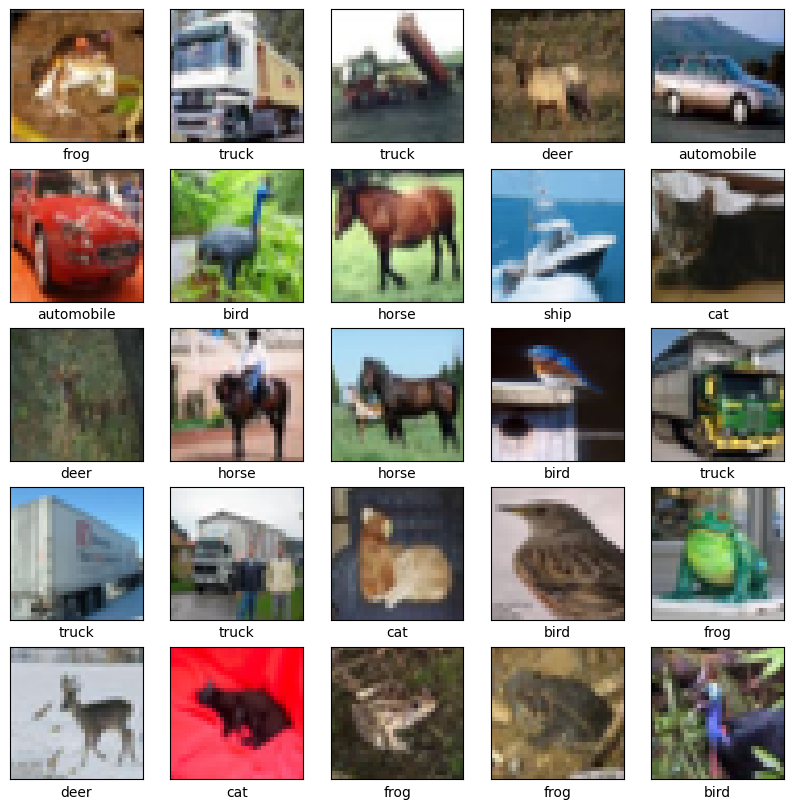

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Creating a CNN model**

We are going to create a CNN based classification model using *keras* module.

In [4]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.3))

model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.4))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288,800 (1.10 MB)

 Trainable params: 287,904 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 560,490 (2.14 MB)

 Trainable params: 559,338 (2.13 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [6]:
model.compile(optimizer='sgd',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=10,validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 415s 263ms/step - accuracy: 0.3568 - loss: 1.7823 - val_accuracy: 0.4770 - val_loss: 1.4229
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 444s 265ms/step - accuracy: 0.4954 - loss: 1.3844 - val_accuracy: 0.5633 - val_loss: 1.2008
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 443s 266ms/step - accuracy: 0.5683 - loss: 1.2063 - val_accuracy: 0.6178 - val_loss: 1.0559
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 440s 265ms/step - accuracy: 0.6038 - loss: 1.1062 - val_accuracy: 0.6126 - val_loss: 1.0996
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 413s 265ms/step - accuracy: 0.6359 - loss: 1.0220 - val_accuracy: 0.6929 - val_loss: 0.8643
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 448s 268ms/step - accuracy: 0.6596 - loss: 0.9621 - val_accuracy: 0.7090 - val_loss: 0.8130
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 438s 265ms/step - accuracy: 0.6818 - loss: 0.9042 - val_accuracy: 0.6962 - val_loss: 0.8573
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 446s 268ms/step - ac

313/313 - 19s - 60ms/step - accuracy: 0.7453 - loss: 0.7162


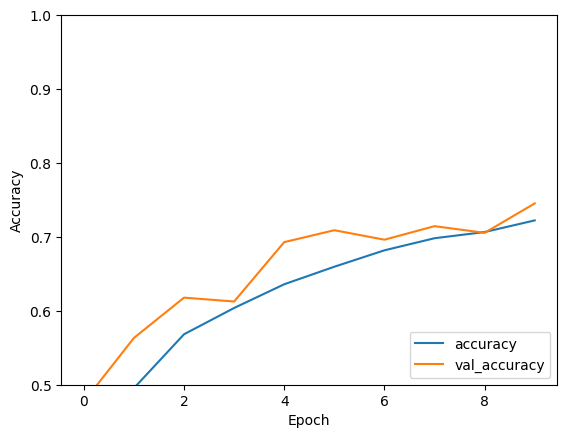

In [7]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [8]:
print(test_acc)

0.7452999949455261


In [35]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

# Define class weights to prioritize Cat (3) and Dog (5)
# We give them a higher weight (e.g., 2.0) compared to other classes (1.0)
class_weight = {i: 1.0 for i in range(10)}
class_weight[3] = 2.5  # Focus more on Cats
class_weight[5] = 2.5  # Focus more on Dogs

# Flatten labels for compatibility with class_weight
train_labels_flat = train_labels.flatten()

history = model.fit(
    train_images,
    train_labels_flat,
    epochs=10,
    validation_data=(test_images, test_labels.flatten()),
    class_weight=class_weight
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 446s 281ms/step - accuracy: 0.8368 - loss: 0.6609 - val_accuracy: 0.8416 - val_loss: 0.4821
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 431s 276ms/step - accuracy: 0.8429 - loss: 0.6322 - val_accuracy: 0.8253 - val_loss: 0.5295
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 431s 276ms/step - accuracy: 0.8489 - loss: 0.6076 - val_accuracy: 0.8417 - val_loss: 0.4763
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 443s 276ms/step - accuracy: 0.8507 - loss: 0.5923 - val_accuracy: 0.8330 - val_loss: 0.5129
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 432s 277ms/step - accuracy: 0.8558 - loss: 0.5754 - val_accuracy: 0.8520 - val_loss: 0.4441
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 432s 277ms/step - accuracy: 0.8606 - loss: 0.5569 - val_accuracy: 0.8494 - val_loss: 0.4542
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 434s 278ms/step - accuracy: 0.8639 - loss: 0.5425 - val_accuracy: 0.8303 - val_loss: 0.5085
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 434s 278ms/step - ac

313/313 - 18s - 59ms/step - accuracy: 0.8485 - loss: 0.4766


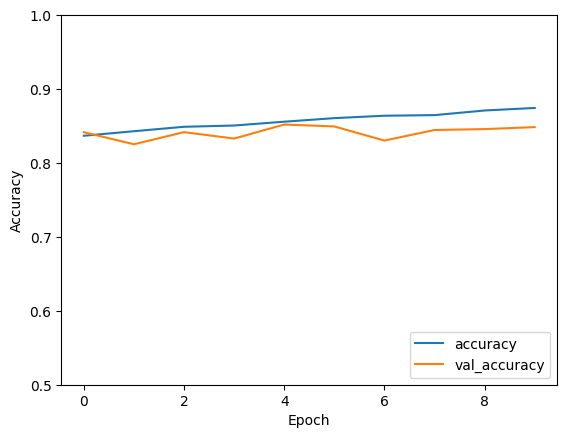

In [37]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

# Flatten test labels to match the training label shape used with class weights
test_labels_flat = test_labels.flatten()
test_loss, test_acc = model.evaluate(test_images, test_labels_flat, verbose=2)

In [38]:
print(test_acc)

0.8485000133514404


In [39]:
# save model
model.save('final_model.keras') #previously saved as 'final_model.h5", a legacy

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
image1.jpg: frog (99.98%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
image2.jpg: airplane (88.16%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
image3.jpg: cat (63.55%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
image4.png: horse (97.97%)


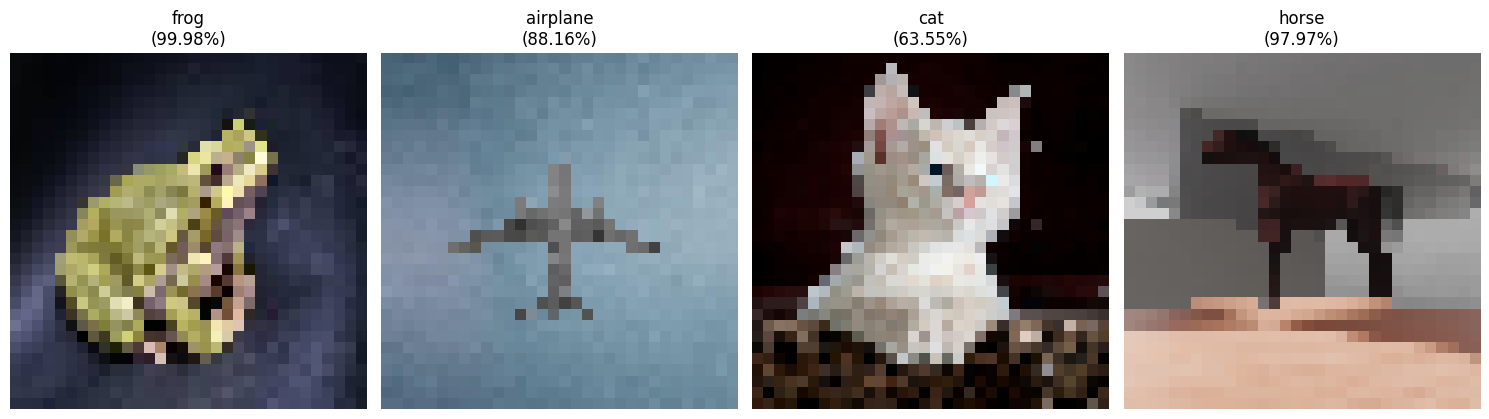

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import preprocessing, models
import tensorflow as tf

# load and prepare the image
def load_image(filename):
	# load the image
	img = preprocessing.image.load_img(filename, target_size=(32, 32))
	# convert to array
	img = preprocessing.image.img_to_array(img)
	# reshape into a single sample with 3 channels
	img_tensor = img.reshape(1, 32, 32, 3)
	# prepare pixel data
	img_tensor = img_tensor.astype('float32')
	img_tensor = img_tensor / 255.0
	return img_tensor, img / 255.0 # Return both the tensor and a displayable version

# load images and predict the classes with confidence
def run_examples(filenames):
	# load model once
	model = models.load_model('final_model.keras')

	plt.figure(figsize=(15, 5))

	for i, filename in enumerate(filenames):
		try:
			# load the image
			img_tensor, processed_img = load_image(filename)
			# predict the class probabilities
			predictions = model.predict(img_tensor)
			# Convert logits to probabilities if necessary
			prob = tf.nn.softmax(predictions[0]).numpy()

			result = np.argmax(prob)
			prediction = class_names[result]
			confidence = prob[result] * 100

			# display the processed image
			plt.subplot(1, len(filenames), i + 1)
			plt.imshow(processed_img)
			plt.title(f"{prediction}\n({confidence:.2f}%)")
			plt.axis('off')
			print(f"{filename}: {prediction} ({confidence:.2f}%)")
		except Exception as e:
			print(f"Could not process {filename}: {e}")

	plt.tight_layout()
	plt.show()

# List of images to predict
image_files = ['image1.jpg', 'image2.jpg', 'image3.jpg', 'image4.png']
run_examples(image_files)

### Fine-tuning for Cat and Dog classes

We will extract only the images corresponding to cats (label 3) and dogs (label 5) and perform transfer learning using our previously trained model.

In [33]:
import numpy as np

# CIFAR-10 indices: cat=3, dog=5
cat_idx, dog_idx = 3, 5

def filter_classes(images, labels):
    mask = (labels.flatten() == cat_idx) | (labels.flatten() == dog_idx)
    filtered_images = images[mask]
    filtered_labels = labels[mask].flatten()
    # Map cat to 0 and dog to 1
    filtered_labels = np.where(filtered_labels == cat_idx, 0, 1)
    return filtered_images, filtered_labels

train_images_cd, train_labels_cd = filter_classes(train_images, train_labels)
test_images_cd, test_labels_cd = filter_classes(test_images, test_labels)

print(f'Training samples: {len(train_images_cd)}')
print(f'Testing samples: {len(test_images_cd)}')

Training samples: 10000
Testing samples: 2000


In [34]:
# Load the base model and freeze convolutional layers
base_model = models.load_model('final_model.keras')
# Keep layers up to the flatten layer (which is at index -6 in the updated model)
# Or create a new model using the layers of the old one

# Alternative: Freeze the existing model layers except the last few dense layers
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Add a new classification head for 2 classes
new_model = models.Sequential(base_model.layers[:-1]) # Remove the last 10-node layer
new_model.add(layers.Dense(2, activation='softmax'))

new_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history_ft = new_model.fit(train_images_cd, train_labels_cd, epochs=5,
                          validation_data=(test_images_cd, test_labels_cd))

new_model.save('fine_tuned_cat_dog.keras')

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.8155 - loss: 0.4215 - val_accuracy: 0.8445 - val_loss: 0.3510
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.8351 - loss: 0.3753 - val_accuracy: 0.8375 - val_loss: 0.3559
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.8376 - loss: 0.3654 - val_accuracy: 0.8425 - val_loss: 0.3550
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.8388 - loss: 0.3601 - val_accuracy: 0.8405 - val_loss: 0.3545
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 76ms/step - accuracy: 0.8445 - loss: 0.3582 - val_accuracy: 0.8440 - val_loss: 0.3580
